# Straight Waveguide Mode-Source Simulation

This notebook is a compact, single-run version of the straight-waveguide setup from the benchmark notebook. It builds one silicon strip waveguide on silica, solves a TE-like mode source, launches that mode in the `+x` direction, shows the geometry, runs the simulation once, and then plots the final `Ey` field slice.

The intent is readability rather than benchmark infrastructure: the only reported throughput is the simulation-only GCUPS from the timed FDTD run. Setup, mode solve, compile setup, XLA compile, and runtime are kept separate so the timing plot remains easy to interpret.

## Imports

Load BeamZ from this local checkout, then NumPy, Matplotlib, and small display/timing utilities used throughout the notebook. The plotting DPI is set once so the diagnostic figures render clearly inline.

In [1]:
# Resolve BeamZ from this checkout before any installed package copy.
from pathlib import Path
import subprocess
import sys

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "beamz" / "__init__.py").exists():
    repo_root = repo_root.parent
if not (repo_root / "beamz" / "__init__.py").exists():
    raise RuntimeError("Could not locate the local BeamZ checkout from the notebook working directory.")

repo_root_str = str(repo_root)
sys.path = [p for p in sys.path if Path(p or ".").resolve() != repo_root]
sys.path.insert(0, repo_root_str)
for module_name in [name for name in tuple(sys.modules) if name == "beamz" or name.startswith("beamz.")]:
    del sys.modules[module_name]

# Standard-library utilities for timing and readable timing output.
import json
import time

# Numerical, plotting, and BeamZ APIs used by the simulation.
import beamz as bz
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

beamz_path = Path(bz.__file__).resolve()
if repo_root not in beamz_path.parents:
    raise RuntimeError(f"BeamZ resolved outside this checkout: {beamz_path}")
branch = subprocess.run(
    ["git", "-C", repo_root_str, "branch", "--show-current"],
    capture_output=True,
    text=True,
    check=False,
).stdout.strip()
print(f"Using local BeamZ from: {beamz_path}")
print(f"Git branch: {branch or '(detached HEAD)'}")

# Use a slightly sharper default for inline notebook figures.
plt.rcParams.update({"figure.dpi": 120})

Using local BeamZ from: /Users/quentinwach/Code/beamz-1/beamz/__init__.py
Git branch: fix_cpml


## Physical Setup

Define the waveguide dimensions, materials, source pulse, grid, CPML boundaries, and a single `FieldMonitor`. The monitor is placed at the vertical center of the silicon core (`z = core_height / 2`) so the final slice cuts through the guided mode rather than the substrate/interface.

The mode source is placed just inside the thicker left CPML and launches explicitly in `+x`. The x-direction CPMLs are `1.2 um` thick, while the transverse CPMLs stay at `0.5 um`. The source transverse plane is requested to be 75% of the previous area, then clamped to the non-PML y/z aperture so the plane does not overlap the transverse CPML regions.

In [2]:
# Use BeamZ microns as the notebook's physical length unit.
um = bz.um

# Define a simple straight silicon strip waveguide on silica.
waveguide_length = 5.0 * um
core_width = 0.445 * um
core_height = 0.220 * um
port_extension = 1.0 * um
background_ext = 0.1 * um

# Build the full simulation domain from the waveguide and surrounding material extents.
full_width = core_width + 2 * port_extension
substrate_height = port_extension
cladding_height = core_height + port_extension
sim_size = (waveguide_length, full_width, substrate_height + cladding_height + background_ext)

# Define the three materials used in the model.
mat_air = bz.Material(permittivity=1.0)
mat_si = bz.Material(permittivity=3.48**2)
mat_sio2 = bz.Material(permittivity=1.45**2)

# Set the optical pulse and ask the mode solver for the fundamental TE-like mode.
lambda0 = 1.55 * um
freq0 = bz.LIGHT_SPEED / lambda0
source_fwidth = freq0 / 10
source_time = bz.GaussianPulse(freq0=freq0, fwidth=source_fwidth)
mode_spec = bz.ModeSpec(num_modes=1, target_neff=0.98 * 3.48, polarization="te")
sparam_freqs = np.linspace(freq0 - 0.5 * source_fwidth, freq0 + 0.5 * source_fwidth, 11)
sparam_wavelengths_um = bz.LIGHT_SPEED / sparam_freqs / um

# Keep the simulation settings intentionally compact for quick notebook iteration.
steps_per_wavelength = 15
run_time = 120 / freq0
pml_x_t = 1.2 * um
pml_transverse_t = 0.5 * um
progress = True
non_pml_x_min = -0.5 * sim_size[0] + pml_x_t
non_pml_x_max = 0.5 * sim_size[0] - pml_x_t

# Place the source and modal diagnostic planes in the non-PML region.
src_x = non_pml_x_min + 0.75 * um
diagnostic_plane_gap = 0.35 * um
source_back_x = max(src_x - diagnostic_plane_gap, non_pml_x_min + 0.2 * um)
source_forward_x = min(src_x + diagnostic_plane_gap, non_pml_x_max - 0.2 * um)

# Construct the material design: silica below, silicon core centered from z=0 to z=core_height.
design = bz.Design(background=mat_air)
design += bz.Box(
    center=(0, 0, -0.5 * sim_size[2]),
    size=(bz.inf, bz.inf, sim_size[2]),
    material=mat_sio2,
)
design += bz.Box(
    center=(0, 0, 0.5 * core_height),
    size=(bz.inf, core_width, core_height),
    material=mat_si,
)

# Shrink the mode and monitor planes to 75% of the previous area, then clamp them away from transverse CPMLs.
previous_source_area_fraction = 0.65
requested_source_area_fraction = previous_source_area_fraction * 0.75
requested_source_plane_scale = np.sqrt(requested_source_area_fraction)
non_pml_y = max(sim_size[1] - 2 * pml_transverse_t, 0.0)
non_pml_z = max(sim_size[2] - 2 * pml_transverse_t, 0.0)
source_plane_y = min(sim_size[1] * requested_source_plane_scale, non_pml_y)
source_plane_z = min(sim_size[2] * requested_source_plane_scale, non_pml_z)
source_plane_size = (0.0, source_plane_y, source_plane_z)
source_plane_area_fraction = (source_plane_y * source_plane_z) / (sim_size[1] * sim_size[2])
source_overlaps_transverse_pml = source_plane_y > non_pml_y or source_plane_z > non_pml_z
src_plane = bz.Box(center=(src_x, 0, 0.0), size=source_plane_size)

# Record Ey on the xy plane through the vertical center of the silicon core.
field_monitor = bz.FieldMonitor(
    center=(0, 0, 0.5 * core_height),
    size=(sim_size[0], sim_size[1], 0.0),
    freqs=sparam_freqs,
    components=("Ey",),
    name="field",
)

# Modal diagnostics: one plane behind the source and one just downstream of it.
modal_monitor_common = dict(
    size=source_plane_size,
    freqs=sparam_freqs,
    mode_spec=mode_spec,
    polarization="te",
    mode_index=0,
)
source_back_monitor = bz.ModeMonitor(
    center=(source_back_x, 0, 0.0),
    direction="+x",
    name="source_back",
    reference_monitor="source_forward",
    **modal_monitor_common,
)
source_forward_monitor = bz.ModeMonitor(
    center=(source_forward_x, 0, 0.0),
    direction="-x",
    name="source_forward",
    **modal_monitor_common,
)

# Create the simulation without sources first so the mode solver sees the same grid and materials.
t0 = time.perf_counter()
sim0 = bz.Simulation(
    domain=sim_size,
    grid_spec=bz.GridSpec.auto(min_steps_per_wvl=steps_per_wavelength, wavelength=lambda0),
    design=design,
    sources=[],
    monitors=[field_monitor, source_back_monitor, source_forward_monitor],
    boundary_spec=bz.BoundarySpec(
        (
            bz.PML(edges=["left", "right"], thickness=pml_x_t, formulation="cpml"),
            bz.PML(
                edges=["bottom", "top", "front", "back"],
                thickness=pml_transverse_t,
                formulation="cpml",
            ),
        )
    ),
    run_time=run_time,
)
setup_wall_s = time.perf_counter() - t0

# Solve the mode on that source plane and convert it into a forward-propagating mode source.
t0 = time.perf_counter()
mode_solver = bz.ModeSolver(simulation=sim0, plane=src_plane, mode_spec=mode_spec, freqs=[freq0])
modes = mode_solver.solve()
mode_source = mode_solver.to_source(
    mode_index=0,
    direction="+x",
    source_time=source_time,
    polarization="te",
    power=1.0,
)
mode_solve_wall_s = time.perf_counter() - t0

# Attach the source while preserving the already-offset monitor from sim0.
sim = sim0.copy(update={"sources": [mode_source]})

# Collect basic grid sizes and derived counts used by the timing summary.
shape_zyx = tuple(int(v) for v in sim.fields.permittivity.shape)
shape_xyz = (shape_zyx[2], shape_zyx[1], shape_zyx[0])
cells = int(np.prod(shape_zyx))

# Print a quick sanity summary before plotting or running the simulation.
print(f"domain = {[v / um for v in sim_size]} um")
print(f"grid xyz = {shape_xyz}")
print(f"cells = {cells:,}")
print(f"steps = {sim.num_steps:,}")
monitors_by_name = {monitor.name: monitor for monitor in sim.monitors}
monitor_z = (sim.monitors[0].plane_position - sim.coordinate_offset[2]) / um
source_x_rel = (mode_source.center[0] - sim.coordinate_offset[0]) / um
source_back_x_rel = (monitors_by_name["source_back"].center[0] - sim.coordinate_offset[0]) / um
source_forward_x_rel = (monitors_by_name["source_forward"].center[0] - sim.coordinate_offset[0]) / um
print(f"sources = {len(sim.sources)}, monitors = {len(sim.monitors)}")
print(f"PML x = {pml_x_t / um:.3f} um, transverse PML = {pml_transverse_t / um:.3f} um")
print(f"physical x window = {non_pml_x_min / um:.3f} to {non_pml_x_max / um:.3f} um")
print(f"field monitor z = {monitor_z:.3f} um")
print(f"source x = {source_x_rel:.3f} um, direction = {mode_source.direction}")
print(f"source-back monitor x = {source_back_x_rel:.3f} um")
print(f"source-forward monitor x = {source_forward_x_rel:.3f} um")
print(f"source plane yz = {source_plane_y / um:.3f} x {source_plane_z / um:.3f} um")
print(f"S-parameter wavelengths = {sparam_wavelengths_um.min():.3f} to {sparam_wavelengths_um.max():.3f} um ({sparam_freqs.size} points)")
print(f"requested source area ratio = {requested_source_area_fraction:.3f}")
print(f"actual source area ratio = {source_plane_area_fraction:.3f}")
print(f"overlaps transverse PML = {source_overlaps_transverse_pml}")
print(f"setup = {setup_wall_s:.3f}s, mode solve = {mode_solve_wall_s:.3f}s")

# Show the solved mode metadata, including the effective index.
display(modes.to_dataframe())

● Done: Raster cache hit (3d): 6e1f987125d92afd67d9a5445f58d92c3e13980dce159bd45aeaf254cc9a9238.npz | load=0.03s
domain = [5.0, 2.445, 2.32] um
grid xyz = (168, 82, 78)
cells = 1,074,528
steps = 10,960
sources = 1, monitors = 3
PML x = 1.200 um, transverse PML = 0.500 um
physical x window = -1.300 to 1.300 um
field monitor z = 0.110 um
source x = -0.550 um, direction = +x
source-back monitor x = -0.900 um
source-forward monitor x = -0.200 um
source plane yz = 1.445 x 1.320 um
S-parameter wavelengths = 1.476 to 1.632 um (11 points)
requested source area ratio = 0.488
actual source area ratio = 0.336
overlaps transverse PML = False
setup = 3.633s, mode solve = 0.204s


,,wavelength,n eff,k eff,loss (dB/cm),TE (Ey) fraction,wg TE fraction,wg TM fraction,mode area
f,mode_index,,,,,,,,
1.934145e+14,0,1.55,2.269523,0.0,0.0,0.964527,0.560302,0.008845,0.14865


## Mode Source Plots

Plot the transverse field components of the solved mode source. This is the first check that the source plane is exciting the intended guided mode rather than a badly clipped or off-center field.

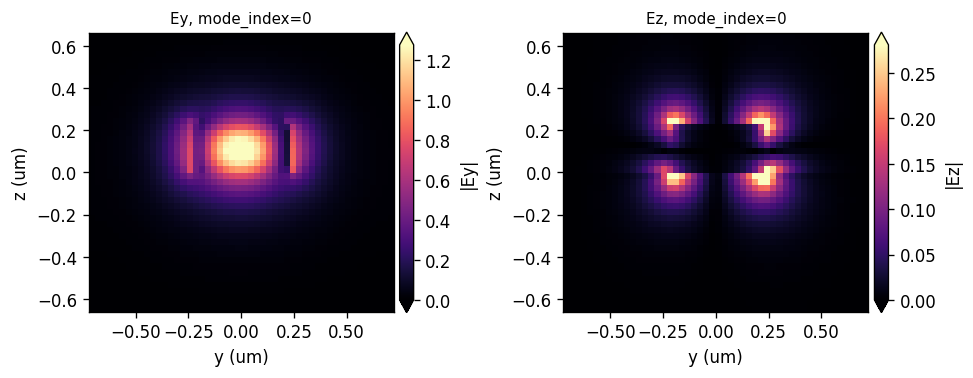

In [3]:
# Plot the magnitude of the dominant TE-like field components on the source plane.
fig, axes, neffs = mode_solver.plot_field_components(
    field_names=("Ey", "Ez"),
    mode_indices=(0,),
    val="abs",
    f=freq0,
    figsize=(8, 5),
    show=False,
)
plt.show()

## 3D Design Viewer

Open the interactive BeamZ 3D viewer for a geometry-level check of the waveguide, mode plane, monitor plane, and CPML placement.

In [4]:
# Display the interactive 3D scene inline in the notebook.
sim.view3d(mode="inline", open_browser=False)

## Layout Cross Sections

Show simple 2D slices through the same simulation object. These static slices are useful when the 3D camera angle makes it hard to judge whether the monitor and waveguide center height are aligned.

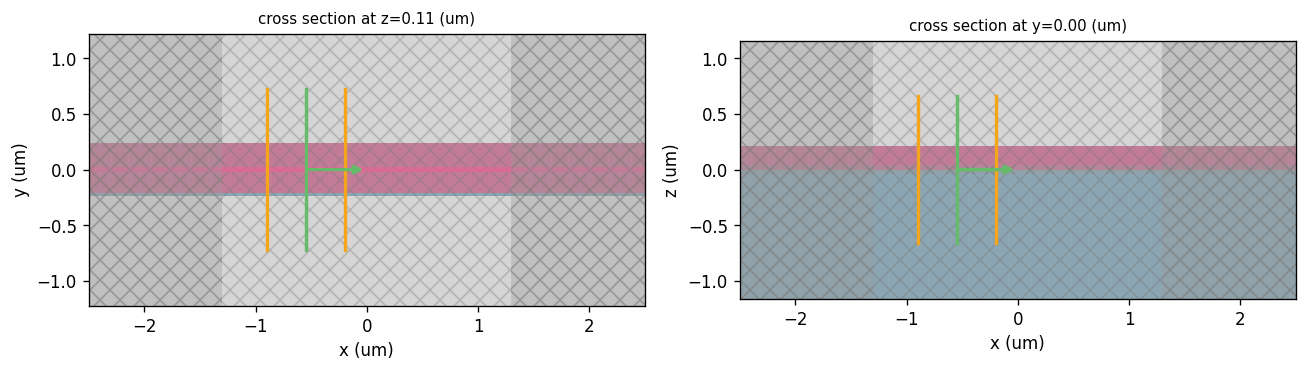

In [5]:
# Plot a horizontal slice through the core center and a vertical slice through y=0.
fig, axes = sim.plot(z=0.5 * core_height, y=0.0, show=False)
plt.show()

## Compile and Run

Compile the simulation, explicitly trigger XLA compilation, then time only the compiled FDTD run. The reported GCUPS uses `cells * timed_steps / run_time`, so setup and compilation are not included in the throughput number.

In [6]:
# Compile the lowered JAX program so XLA compile time is separated from FDTD runtime.
def compile_xla(sim, program):
    """Return wall time for JAX/XLA compilation of the compiled scan."""
    if getattr(program, "_compiled_scan", None) is None:
        program._build_scan()

    # Build the exact runtime inputs used by run_compiled.
    engine_state, monitor_state = sim._compiled_runtime_inputs(program)
    snapshot_state = program._empty_snapshot_state()
    args = (engine_state, monitor_state, program._update_coefficients())
    if snapshot_state is not None:
        args = (*args, snapshot_state)

    # Lower and compile the scan, then cache it on the program object.
    t0 = time.perf_counter()
    program._compiled_scan = program._compiled_scan.lower(*args).compile()
    return time.perf_counter() - t0


# Run all remaining steps from the initial simulation state.
timed_steps = int(sim.num_steps - sim.current_step)

# Measure BeamZ compile/setup time separately from XLA compilation.
compile_start = time.perf_counter()
program = sim.compile(num_steps=timed_steps)
compile_setup_wall_s = time.perf_counter() - compile_start
xla_compile_wall_s = compile_xla(sim, program)

# Time the compiled FDTD execution only.
run_start = time.perf_counter()
sim_data = sim.run_compiled(num_steps=timed_steps, progress=progress)
run_wall_s = time.perf_counter() - run_start

# Convert the run timing into simulation-only GCUPS.
gcups = cells * timed_steps / run_wall_s / 1e9
timing = {
    "setup_wall_s": setup_wall_s,
    "mode_solve_wall_s": mode_solve_wall_s,
    "compile_setup_wall_s": compile_setup_wall_s,
    "xla_compile_wall_s": xla_compile_wall_s,
    "run_wall_s": run_wall_s,
    "cells": cells,
    "timed_steps": timed_steps,
    "cell_updates": int(cells * timed_steps),
    "simulation_only_gcups": gcups,
}

# Print machine-readable and human-readable timing summaries.
print(json.dumps(timing, indent=2))
print(f"simulation-only GCUPS = {gcups:.3f}")

● JIT compiling v0.3 packed FDTD program... done!
● Progress: 100% (10960/10960 steps)
{
  "setup_wall_s": 3.632899667019956,
  "mode_solve_wall_s": 0.20420329202897847,
  "compile_setup_wall_s": 3.6656718329759315,
  "xla_compile_wall_s": 0.5826512919738889,
  "run_wall_s": 83.82326395902783,
  "cells": 1074528,
  "timed_steps": 10960,
  "cell_updates": 11776826880,
  "simulation_only_gcups": 0.1404959234915551
}
simulation-only GCUPS = 0.140


## Modal S-Parameter Diagnostics

Use the downstream source-side mode monitor as the incident reference plane, then plot both modal wave directions at both source-side monitors. This separates backward source injection behind the source from backward guided power returning from the right-side CPML.

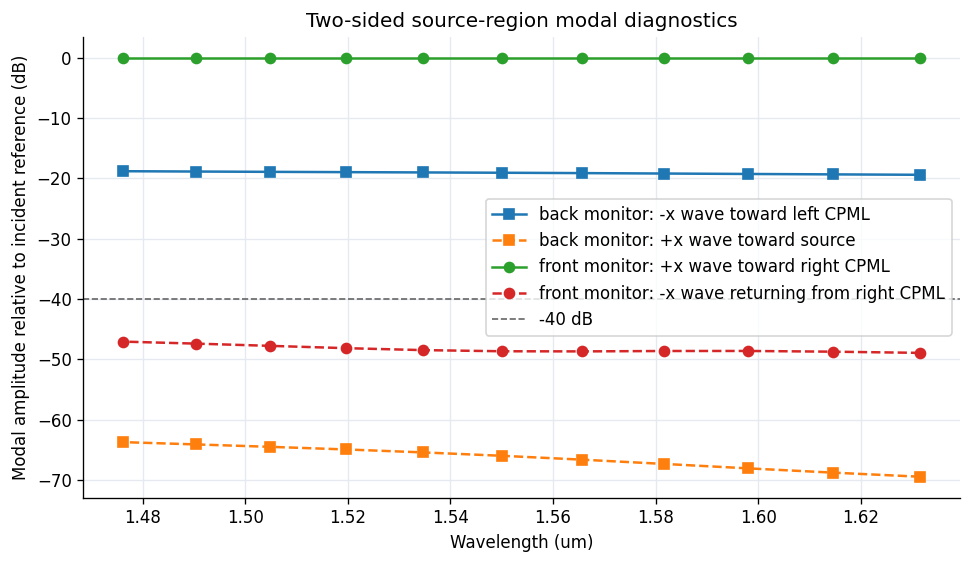

center wavelength = 1.5500 um
incident reference component = a_incident_minus
back monitor: -x wave toward left CPML = -19.05 dB
back monitor: +x wave toward source = -66.02 dB
front monitor: +x wave toward right CPML = -0.00 dB
front monitor: -x wave returning from right CPML = -48.67 dB
valid frequency bins = 11/11


{'wavelength_um': array([1.63157895, 1.61458333, 1.59793814, 1.58163265, 1.56565657,
        1.55      , 1.53465347, 1.51960784, 1.50485437, 1.49038462,
        1.47619048]),
 'back_monitor_minus_x_db': array([-19.39030385, -19.32301469, -19.25331144, -19.1806138 ,
        -19.11085168, -19.05005197, -18.99834908, -18.95072177,
        -18.90203479, -18.85027565, -18.79601227]),
 'back_monitor_plus_x_db': array([-69.49417544, -68.81448905, -68.10068382, -67.36986962,
        -66.66254824, -66.01930269, -65.45657093, -64.96754086,
        -64.53326795, -64.13270647, -63.75306436]),
 'front_monitor_plus_x_db': array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.92865493e-15, -9.64327467e-16,  0.00000000e+00,  0.00000000e+00,
         1.92865493e-15,  0.00000000e+00,  1.92865493e-15]),
 'front_monitor_minus_x_db': array([-48.94205843, -48.7433334 , -48.62322485, -48.63275573,
        -48.69569218, -48.67319953, -48.48424937, -48.15981014,
        -47.7774

In [7]:
# Explicit modal wave selectors for BeamZ's x-directed 3D mode convention.
source_port = bz.PortSpec(
    name="source_back",
    monitor_name="source_back",
    reference_monitor="source_forward",
    direction="+x",
    polarization="te",
    mode_index=0,
    incident_wave="minus",
    scattered_wave="plus",
)
forward_port = bz.PortSpec(
    name="source_forward",
    monitor_name="source_forward",
    direction="-x",
    polarization="te",
    mode_index=0,
    incident_wave="minus",
    scattered_wave="plus",
)
modal_ports = [source_port, forward_port]

sparam_result = sim.get_S_matrix_modal_dft(
    source_port=source_port,
    ports=modal_ports,
    output_ports=modal_ports,
    frequencies=sparam_freqs,
    as_sax=False,
    return_diagnostics=True,
    min_incident_db=-45.0,
)
waves = sparam_result["diagnostics"]["waves"]
source_incident_selector = str(source_port.incident_wave).lower()
a_incident = np.asarray(
    waves["source_back"][f"a_incident_{source_incident_selector}"],
    dtype=np.complex128,
)
valid = np.asarray(sparam_result["diagnostics"]["valid_mask"], dtype=bool)

def safe_ratio(numerator, denominator, floor=1e-18):
    numerator = np.asarray(numerator, dtype=np.complex128)
    denominator = np.asarray(denominator, dtype=np.complex128)
    return np.where(np.abs(denominator) >= floor, numerator / denominator, 0.0 + 0.0j)

def amp_db(values, floor=1e-12):
    return 20.0 * np.log10(np.maximum(np.abs(values), floor))

# For x-directed 3D modal projections in BeamZ, minus is the wave moving in
# the PortSpec direction and plus is the opposite-going wave.
modal_traces = {
    "back monitor: -x wave toward left CPML": safe_ratio(waves["source_back"]["a_plus"], a_incident),
    "back monitor: +x wave toward source": safe_ratio(waves["source_back"]["a_minus"], a_incident),
    "front monitor: +x wave toward right CPML": safe_ratio(waves["source_forward"]["a_plus"], a_incident),
    "front monitor: -x wave returning from right CPML": safe_ratio(waves["source_forward"]["a_minus"], a_incident),
}

fig, ax = plt.subplots(figsize=(8.2, 4.8))
styles = ["s-", "s--", "o-", "o--"]
for (label, values), style in zip(modal_traces.items(), styles):
    ax.plot(sparam_wavelengths_um, amp_db(values), style, label=label)
if not np.all(valid):
    ax.scatter(sparam_wavelengths_um[~valid], amp_db(a_incident)[~valid], marker="x", color="k", label="low incident bin")
ax.axhline(-40.0, color="#666666", lw=1, ls="--", label="-40 dB")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Modal amplitude relative to incident reference (dB)")
ax.set_title("Two-sided source-region modal diagnostics")
ax.grid(True, color="#e6e9ef")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

center_idx = int(np.argmin(np.abs(sparam_freqs - freq0)))
print(f"center wavelength = {sparam_wavelengths_um[center_idx]:.4f} um")
print(f"incident reference component = a_incident_{source_incident_selector}")
for label, values in modal_traces.items():
    print(f"{label} = {amp_db(values)[center_idx]:.2f} dB")
print(f"valid frequency bins = {int(np.count_nonzero(valid))}/{valid.size}")
sparam_table = {
    "wavelength_um": sparam_wavelengths_um,
    "back_monitor_minus_x_db": amp_db(modal_traces["back monitor: -x wave toward left CPML"]),
    "back_monitor_plus_x_db": amp_db(modal_traces["back monitor: +x wave toward source"]),
    "front_monitor_plus_x_db": amp_db(modal_traces["front monitor: +x wave toward right CPML"]),
    "front_monitor_minus_x_db": amp_db(modal_traces["front monitor: -x wave returning from right CPML"]),
    "valid": valid,
}
display(sparam_table)

## Final Ey Field Slice

Plot the recorded `Ey` field from the monitor plane at `z = core_height / 2`, cropped to the non-PML x-window so the absorber's nonphysical stretched-coordinate decay does not dominate the visual read.

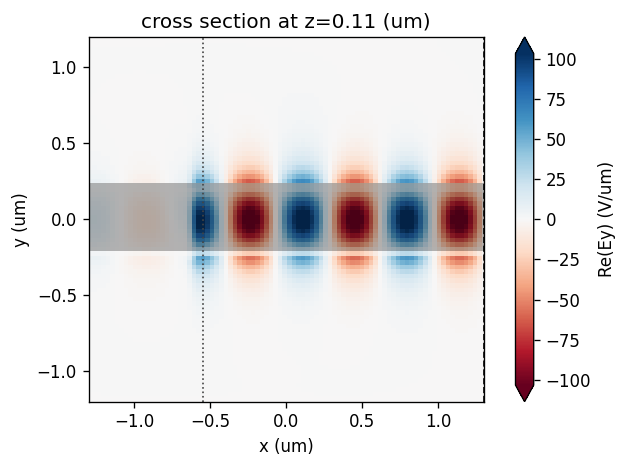

In [8]:
# Plot the real part of Ey on the monitor plane through the waveguide center height.
# Crop to the non-PML region; fields inside CPML are intentionally nonphysical.
fig, ax = sim_data.plot_field(
    "field",
    "Ey",
    frequency=freq0,
    val="real",
    cmap="RdBu",
    xlim=(non_pml_x_min / um, non_pml_x_max / um),
    ylim=(-1.2, 1.2),
)
ax.axvline(non_pml_x_min / um, color="k", lw=1, ls="--")
ax.axvline(non_pml_x_max / um, color="k", lw=1, ls="--")
ax.axvline(src_x / um, color="#444444", lw=1, ls=":")
plt.show()

## Timing Summary

Summarize setup, mode solve, compile setup, XLA compile, and simulation runtime in one compact horizontal bar chart. The title reports the simulation-only throughput from the compiled run.

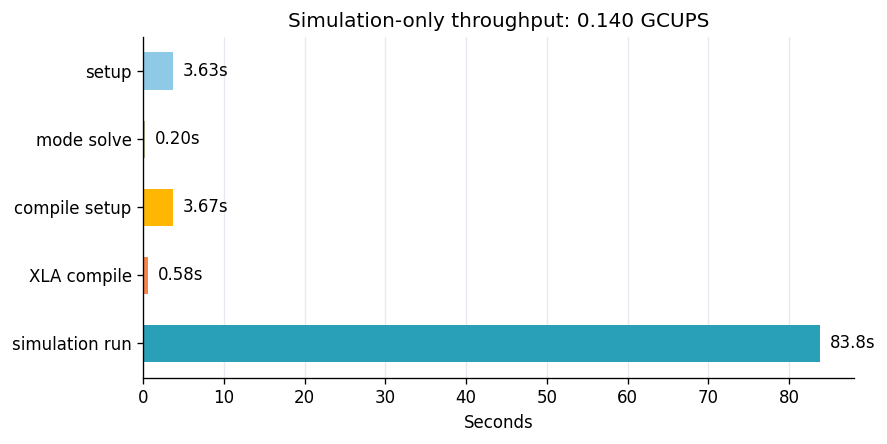

In [9]:
# Prepare the timing categories in the order they occurred.
labels = ["setup", "mode solve", "compile setup", "XLA compile", "simulation run"]
values = [
    timing["setup_wall_s"],
    timing["mode_solve_wall_s"],
    timing["compile_setup_wall_s"],
    timing["xla_compile_wall_s"],
    timing["run_wall_s"],
]
colors = ["#8ecae6", "#a3b18a", "#ffb703", "#f9844a", "#2a9fb8"]

# Draw a horizontal timing chart with labels at the end of each bar.
fig, ax = plt.subplots(figsize=(7.5, 3.8))
y = np.arange(len(labels))
ax.barh(y, values, color=colors, height=0.55)
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xlabel("Seconds")
ax.grid(axis="x", color="#e6e9ef")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
for yi, value in zip(y, values):
    text = f"{value:.2f}s" if value < 10 else f"{value:.1f}s"
    ax.annotate(text, (value, yi), xytext=(6, 0), textcoords="offset points", va="center")
ax.set_title(f"Simulation-only throughput: {gcups:.3f} GCUPS")
fig.tight_layout()
plt.show()